## Decoding Philadelphia's Shooting Data 

Philadelphia is a city of neighborhoods, history, and heart. But beneath the surface of the "City of Brotherly Love" lies a complex reality captured in rows and columns of data. In this post, we look beyond the headlines to see what the numbers tell us about gun violence in our city

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import Point
import geopandas as gpd

df = pd.read_csv('openphilly_data_shootings.csv')
df = df[df['year'] < 2026]
df['date_'] = pd.to_datetime(df['date_'])


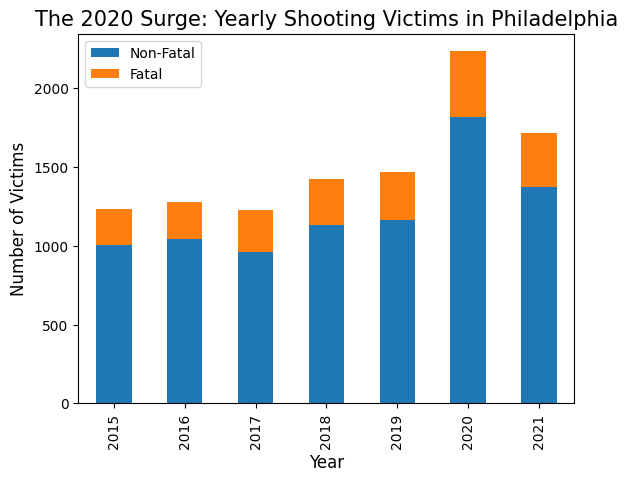

In [25]:
yearly_stats = df.groupby(['year', 'fatal']).size().unstack()

yearly_stats.plot(kind='bar', stacked=True)
plt.title('The 2020 Surge: Yearly Shooting Victims in Philadelphia', fontsize=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Victims', fontsize=12)
plt.legend(['Non-Fatal', 'Fatal'])

When we look at the total number of shooting victims year-over-year, a startling pattern emerges. For years, the numbers hovered around 1,200 to 1,400. The sudden jump in 2020 is strange. If anything, you would think lockdowns may have caused fewer shootings, but this time of crisis saw a huge jump in shootings, and the number began correcting in 2021.

Text(0, 0.5, 'Total Victims')

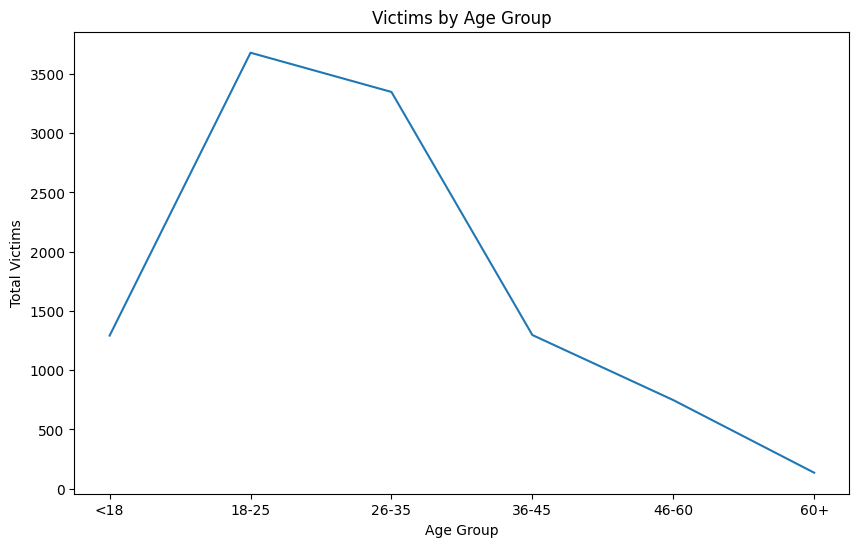

In [26]:
age_bins = [0, 18, 25, 35, 45, 60, 100]
age_labels = ['<18', '18-25', '26-35', '36-45', '46-60', '60+']
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels)

plt.figure(figsize=(10, 6))
df['age_group'].value_counts().sort_index().plot(kind='line')
plt.title('Victims by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Victims')

The numbers tell us when, but who are they talking about? When we break down the demographics, we see that gun violence isn't distributed evenly across the population. It is a crisis that disproportionately affects young people, particularly those between the ages of 18 and 35. This "demographic of vulnerability" represents the future of the city, highlighting the true cost of every incident.

/tmp/ipykernel_3200664/3010785248.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['hour'] = pd.to_datetime(df['time']).dt.hour


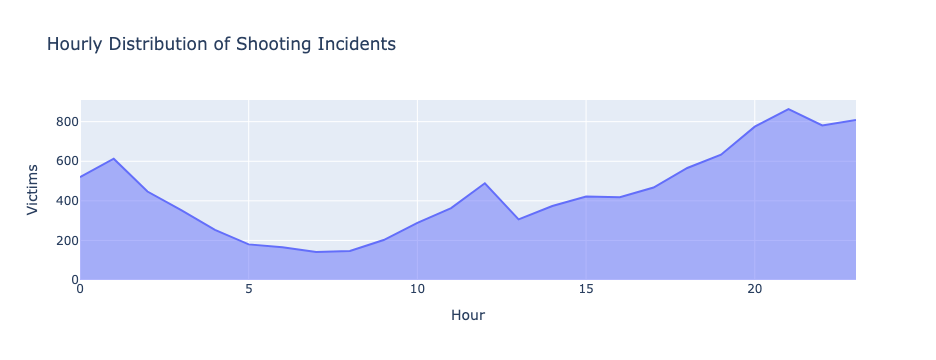

In [27]:
import plotly.express as px
df['hour'] = pd.to_datetime(df['time']).dt.hour

hourly_df = df['hour'].value_counts().sort_index().reset_index()
hourly_df.columns = ['Hour', 'Victims']

fig = px.area(hourly_df, x='Hour', y='Victims', 
              title='Hourly Distribution of Shooting Incidents',
              labels={'Hour', 'Victims'})

fig.show()

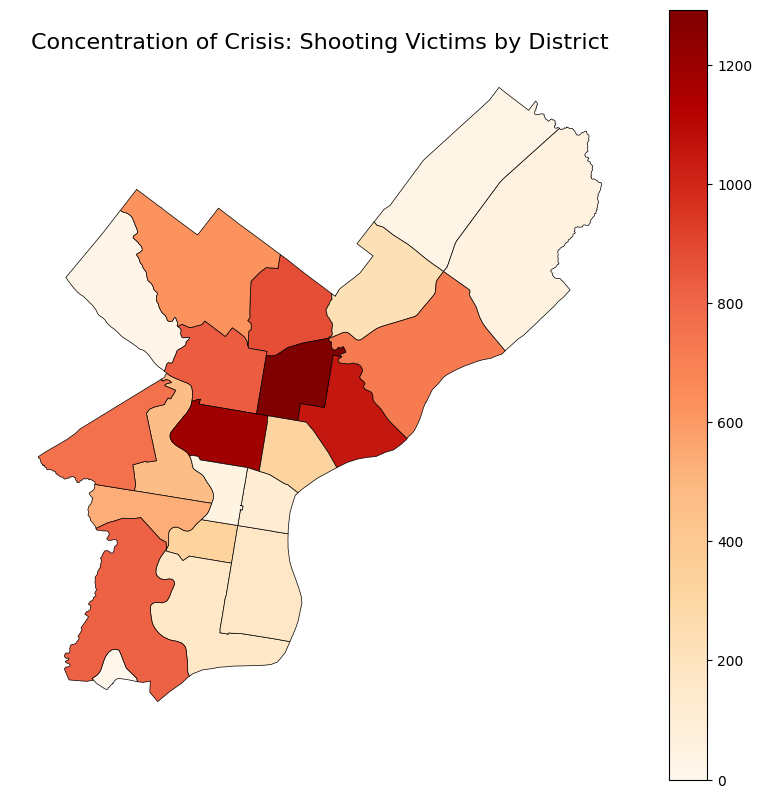

In [33]:
shoot_by_dist = df['dist'].value_counts().reset_index()
shoot_by_dist.columns = ['DIST_NUM', 'count']
districts_gdf['DIST_NUM'] = districts_gdf['DIST_NUM'].astype(float)
map_gdf = districts_gdf.merge(shoot_by_dist, on='DIST_NUM', how='left').fillna(0)

fig, ax = plt.subplots(figsize=(10, 10))
map_gdf.plot(column='count', cmap='OrRd', edgecolor='black', linewidth=0.5, legend=True, ax=ax)
plt.title('Concentration of Crisis, fontsize=16)
ax.axis('off')
plt.show()

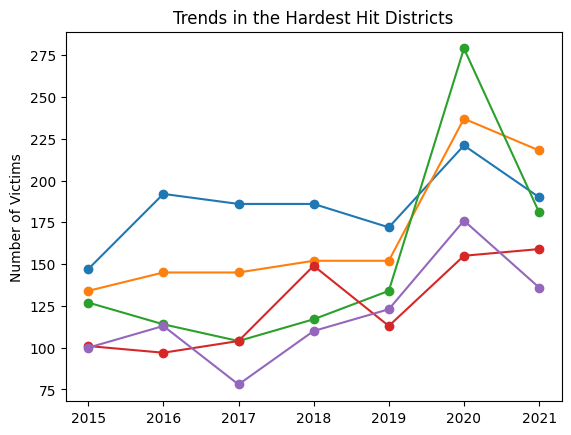

In [36]:
top_5_dists = df['dist'].value_counts().nlargest(5).index
trend_df = df[df['dist'].isin(top_5_dists)].groupby(['year', 'dist']).size().unstack().fillna(0)

for dist in top_5_dists:
    plt.plot(trend_df.index, trend_df[dist], marker='o', label=f'District {int(dist)}')
plt.title('Trends in the Hardest Hit Districts')
plt.ylabel('Number of Victims')
plt.show()

But here is the twist, while the 2020 surge hit the whole city, districts like the 25th were already seeing a steady, year-over-year rise long before the pandemic. By comparing the hardest-hit districts, we see that some neighborhoods were facing a crisis that was "hidden" in the city-wide averages.

**Conclusion**

Our data story reveals a complex, interconnected crisis. It’s not just a "city-wide" problem. It's a specific demographic (youth) caught in a specific timing (late night) within specific neighborhoods (the 25th and 24th districts).

To change the story for Philadelphia, we must focus intervention where the map is darkest and during the hours when the rhythm is highest. By protecting our most vulnerable streets, we take the first step toward a safer, more resilient city.